# MKK Spectra Types

Plot of optical spectra of representative stellar dwarf spectral types.

All of these are dwarf stars, types O5 thru M5, from *A Library of Stellar Spectra* by Jacoby, Hunter, & 
Christian [1984, ApJ, 56, 257](http://adsabs.harvard.edu/abs/1984ApJS...56..257J).  Data have been rescaled 
to have unity flux at 5500A and then were shifted by an arbitrary consant so that they will appear in a 
vertical stack without overlaps.

In [1]:
%matplotlib inline

import os
import sys
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

from astropy.io import fits

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

#### Figure Filename

`figName` sets the figure filename of the form `Fig<chapterNum>_<figNum>`, the figure number may also 
include a lowercase  letter for a subfigure (e.g., Fig1_2a).  

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [2]:
figName = 'MK_dwarfs_16x9' 
plotLumClass = True

# graphic aspect ratio = width/height

# aspect = 4.0/3.0 # 4:3 landscape mode
#aspect = 3.0/4.0 # 4:3 portrait mode
aspect = 16.0/9.0 # wide-screen landscape mode

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
# Plot filename

plotFile = f'{figName}.{figFmt}'

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

# print a summary (uncomment as needed)

print(f'Filename: {plotFile}')
print(f'Size: {wInches:.2f} x {hInches:.2f}-in ({plotWidth} x {plotHeight} pix)')
print(f'Aspect Ratio: {aspect:.2f}:1')
print(f'Fonts: axes={axisFontSize:.1f} pt, intraplot labels={labelFontSize:.1f}')


Filename: MK_dwarfs_16x9.png
Size: 6.00 x 3.38-in (3600.0 x 2025.0 pix)
Aspect Ratio: 1.78:1
Fonts: axes=10.0 pt, intraplot labels=8.0


## Data Files

The file named `mkData.txt` in the `MKTypes/` subfolder is a list of the spectrum files and their associated
spectral type. All are luminosity class V (dwarfs), but we don't note this in the plot below 
(easy enough to restore if needed).

In [3]:
dataFile = 'MKTypes/mkData.txt'
specUnits = 'nm' # or AA

data = pd.read_csv(dataFile,sep=r'\s+',comment='#')
fileNames = np.array(data['filename'])
spTypes = np.array(data['SpType'])

if specUnits == 'nm':
    lMin = 315.0
    lMax = 755.0
    lMajor = 50
    lMinor = 10
    labOff = 3.5
    lamScale = 0.1
else:
    lMin = 3150.0
    lMax = 7550.0
    lMajor = 500
    lMinor = 100
    labOff = 35.
    lamScale = 1.0
    
fMin = -0.95
fMax = 20.95

## MK Spectral Types

Plot the spectral stack from O5 through M5, labeling the spectral type at the left of the plot.  Axes are linear, with wavelength in Angstroms and fluxes are normalized $f_\lambda$.

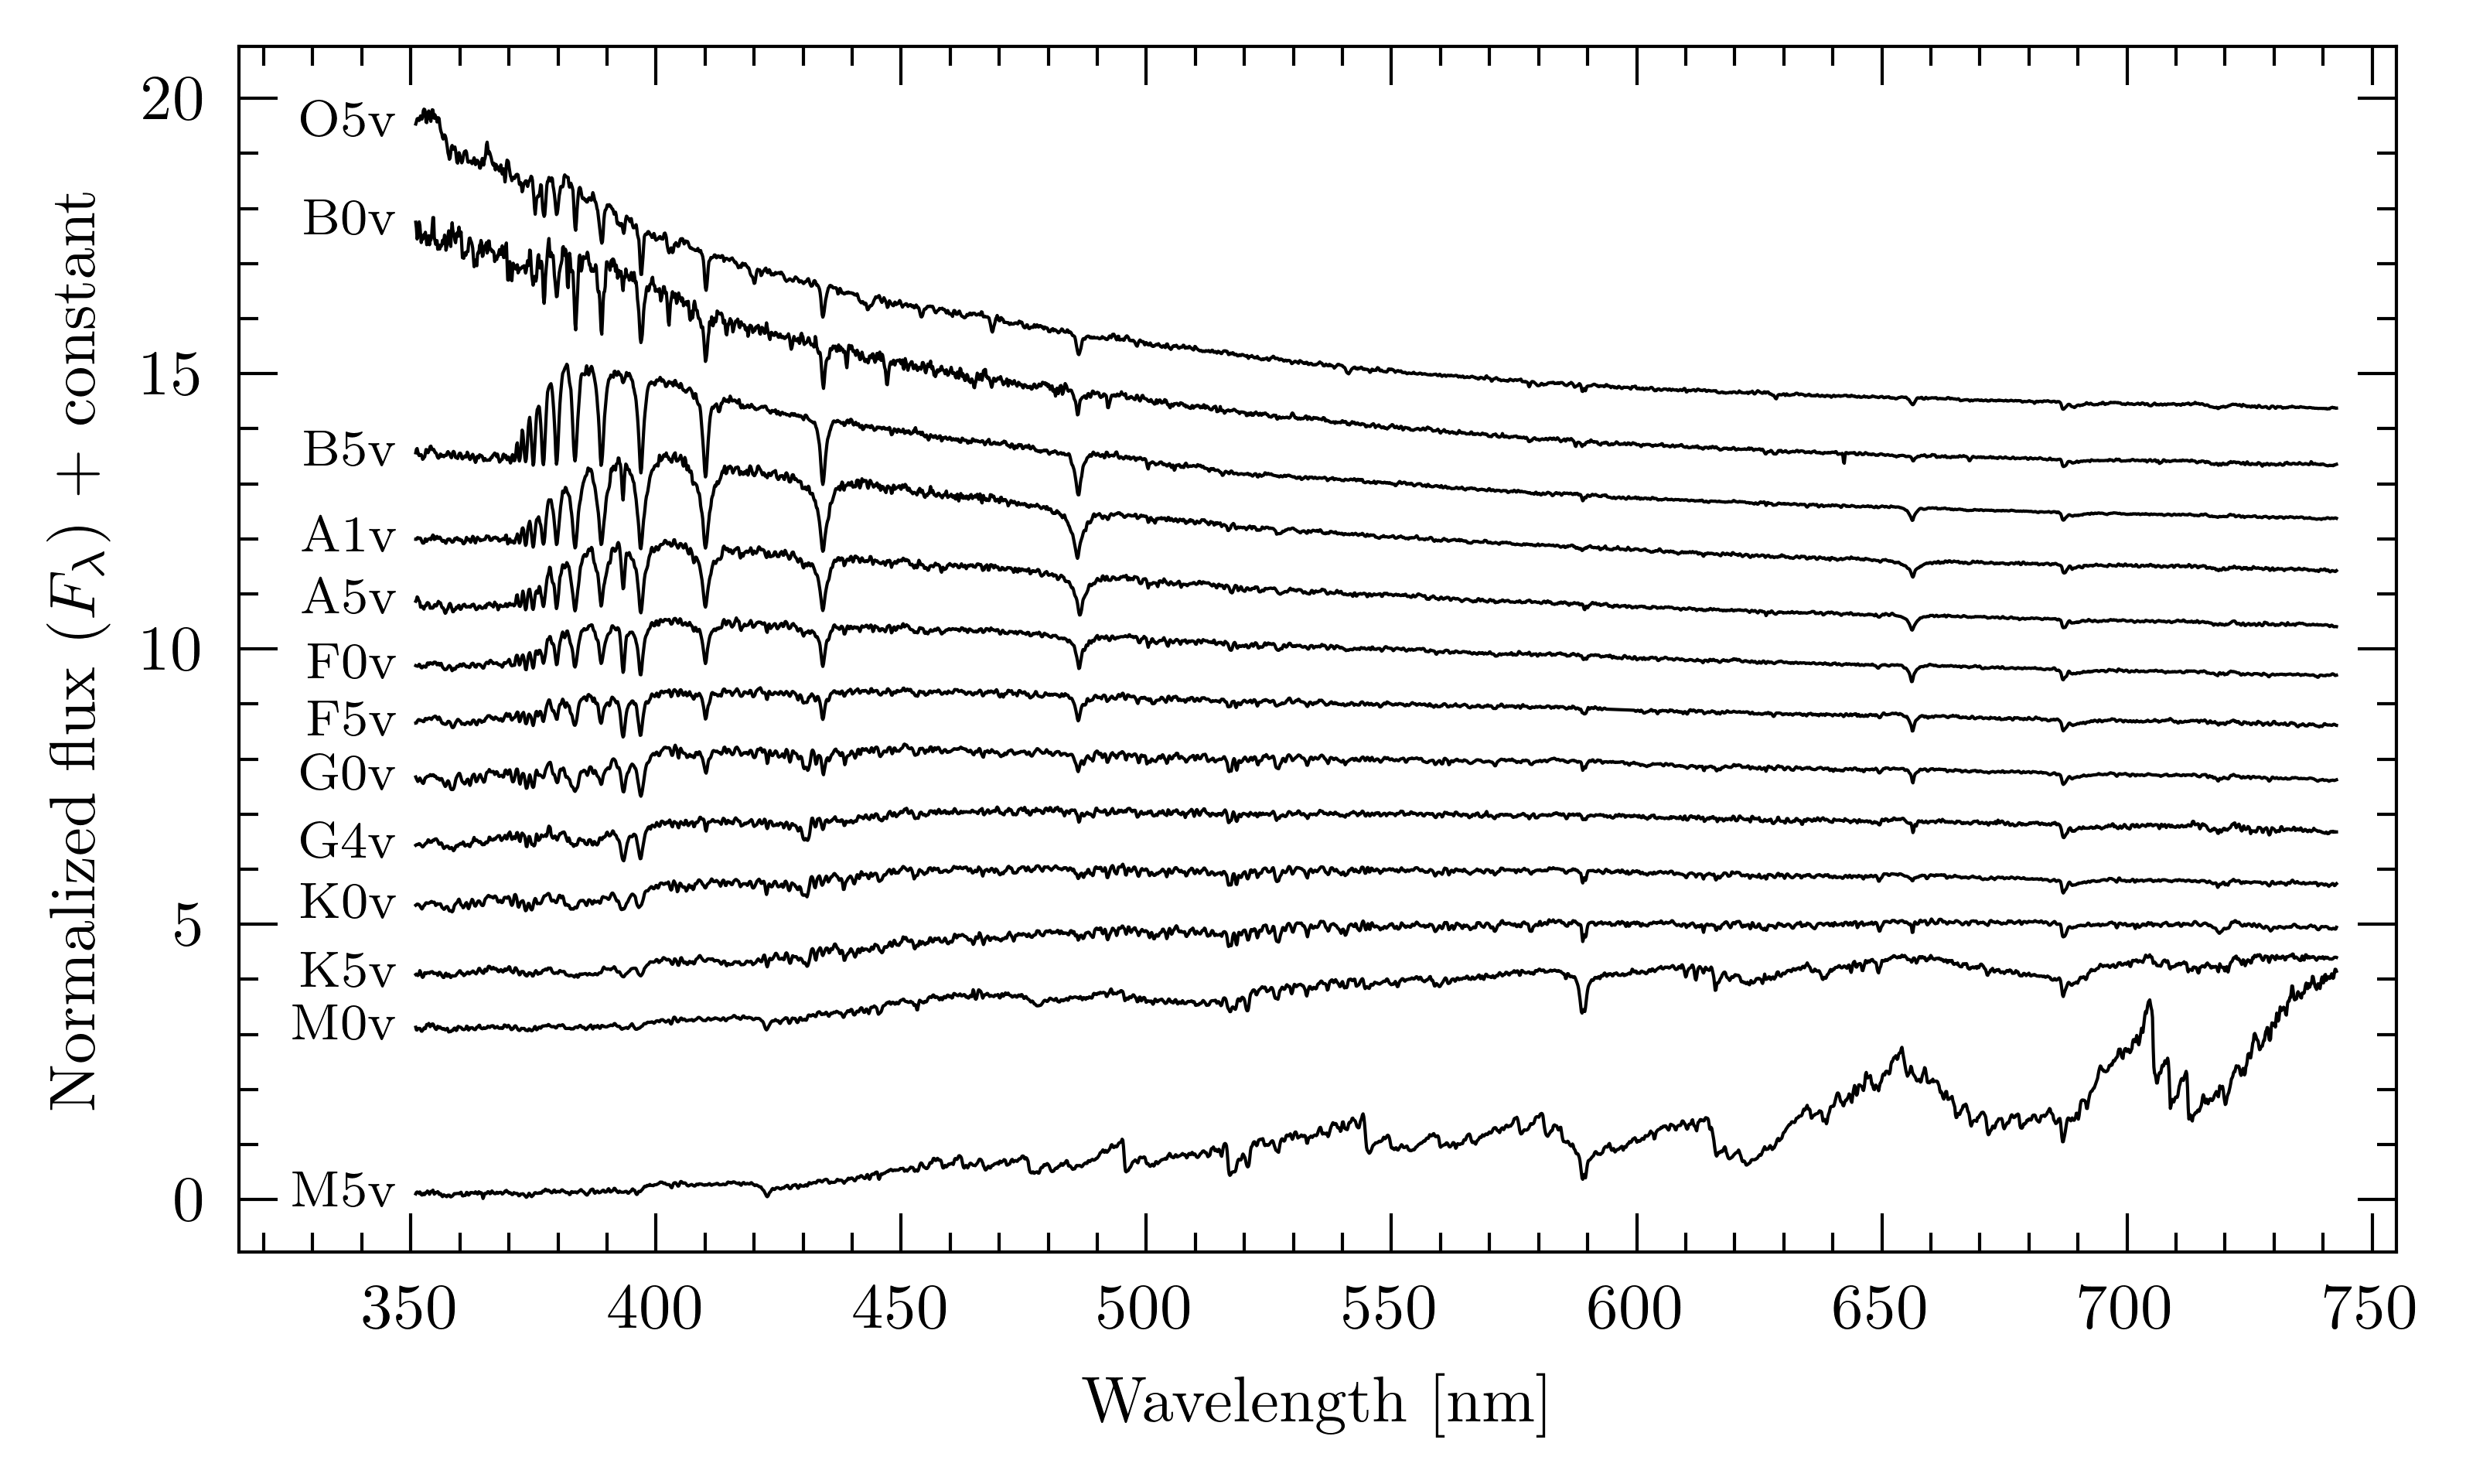

In [4]:
plotFile = 'MK_dwarfs_16x9.png' 

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

ax.set_xlim(lMin,lMax)
ax.xaxis.set_major_locator(MultipleLocator(lMajor))
ax.xaxis.set_minor_locator(MultipleLocator(lMinor))
if specUnits == 'nm':
    ax.set_xlabel(r'Wavelength [nm]',fontsize=axisFontSize)
else:
    ax.set_xlabel(r'Wavelength [\AA]',fontsize=axisFontSize)

ax.set_ylim(fMin,fMax)
ax.yaxis.set_major_locator(MultipleLocator(5.0))
ax.yaxis.set_minor_locator(MultipleLocator(1.0))
ax.set_ylabel(r'Normalized flux ($F_\lambda$) + constant',fontsize=axisFontSize)

for i, file in enumerate(fileNames):
    specFile = f'MKTypes/{file}'
    specData = pd.read_csv(specFile,sep=r'\s+',comment='#')
    lam = lamScale*np.array(specData['Wave'])
    flam = np.array(specData['Flux'])
    ax.plot(lam,flam,'-',color='black',lw=0.5)
    if plotLumClass:
        ax.text(lam[0]-labOff,flam[0],f'{spTypes[i]}v',va='center',ha='right',fontsize=labelFontSize)
    else:
        ax.text(lam[0]-labOff,flam[0],f'{spTypes[i]}',va='center',ha='right',fontsize=labelFontSize)
        

#plt.title('Dwarf Stars (Luminosity Class V)',fontsize=axisFontSize)

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')
plt.show()

## Hydrogen, helium, and calcium lines

Zoom in on the blue part of the spectrum and label the hydrogen, helium, and CaII lines of interest in
spectral types 

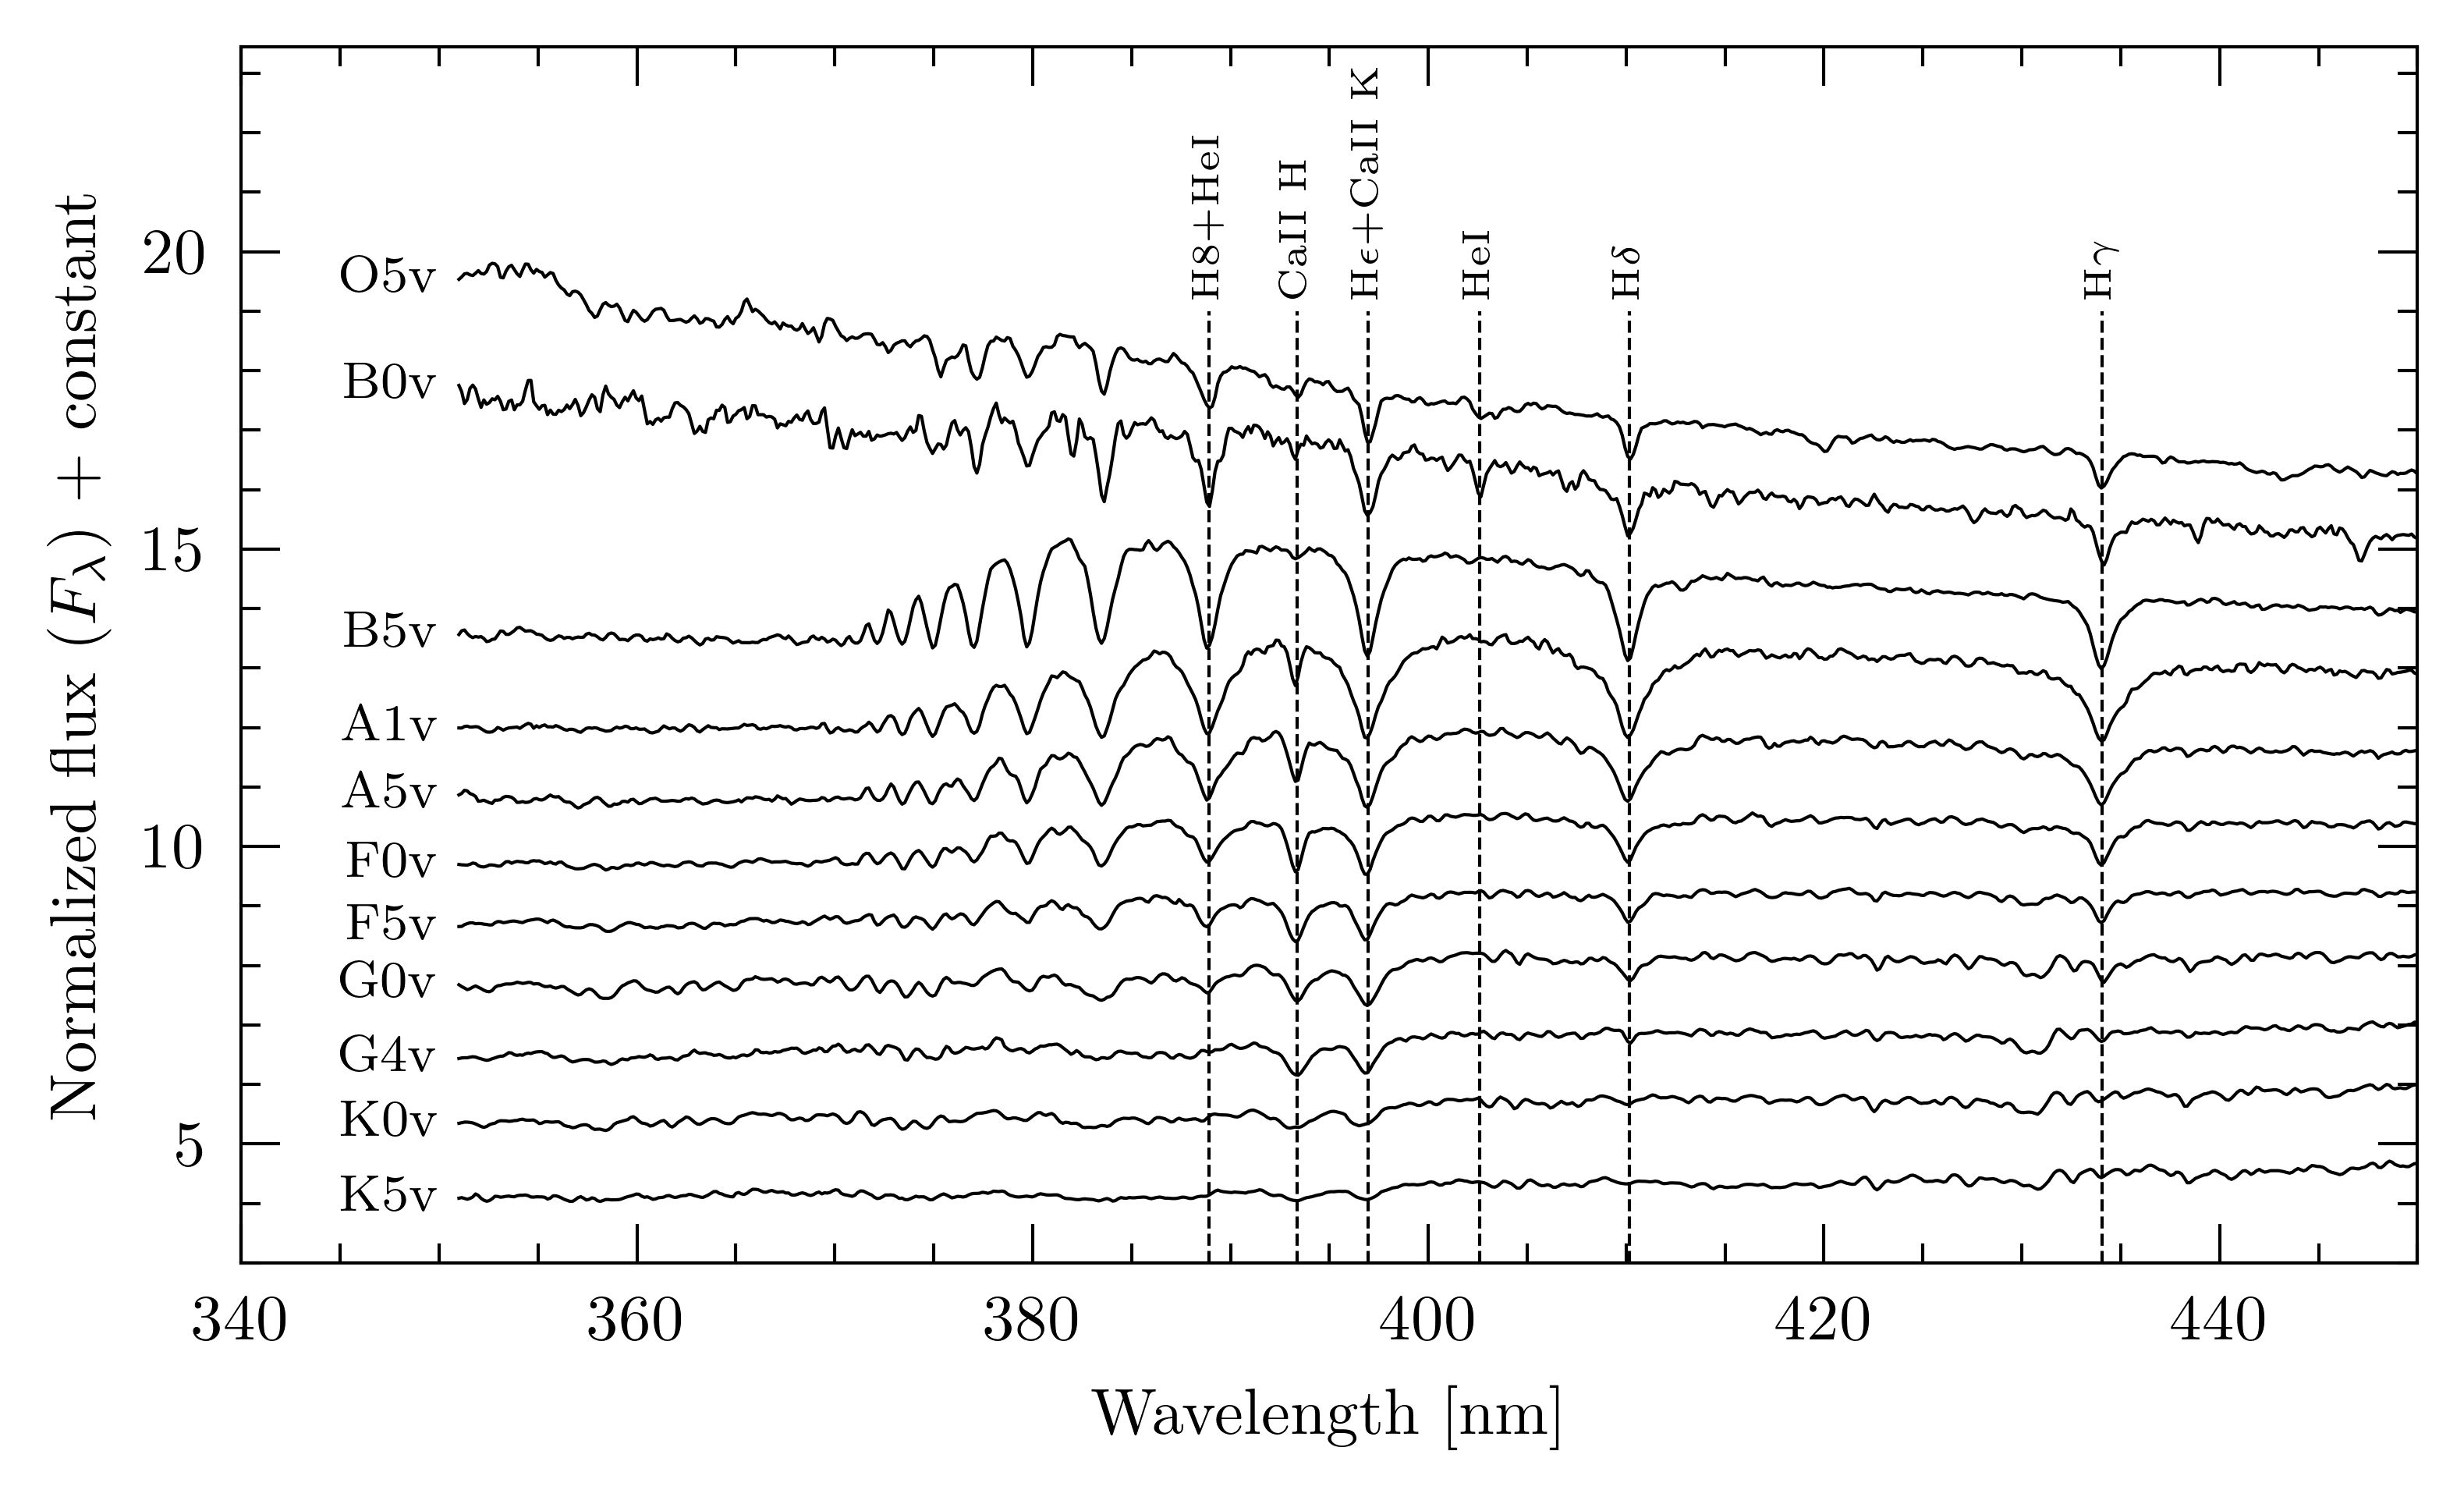

In [5]:
plotFile = 'MK_blueLines.png' 

# wavelength region of interest

lMin = lamScale*3400.0
lMax = lamScale*4500.0
lMajor = lamScale*200.
lMinor = lamScale*50.0
labOff = lamScale*10.0
fMin = 3

# Lines of interest

absLines = ['H8+HeI','CaII H',r'H$\epsilon$+CaII K','HeI',r'H$\delta$',r'H$\gamma$']
lamLines = [3889,3933.663,3969.496,4026,4101.73,4340.46]
fTop = 19.0

# 

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

plt.xlim(lMin,lMax)
ax.xaxis.set_major_locator(MultipleLocator(lMajor))
ax.xaxis.set_minor_locator(MultipleLocator(lMinor))
if specUnits == 'nm':
    plt.xlabel(r'Wavelength [nm]',fontsize=axisFontSize)
else:
    plt.xlabel(r'Wavelength [\AA]',fontsize=axisFontSize)

plt.ylim(fMin,fMax+2.5)
ax.yaxis.set_major_locator(MultipleLocator(5.0))
ax.yaxis.set_minor_locator(MultipleLocator(1.0))
plt.ylabel(r'Normalized flux ($F_\lambda$) + constant',fontsize=axisFontSize)

for i, file in enumerate(fileNames[0:-2]):
    specFile = f'MKTypes/{file}'
    specData = pd.read_csv(specFile,sep=r'\s+',comment='#')
    lam = lamScale*np.array(specData['Wave'])
    flam = np.array(specData['Flux'])
    plt.plot(lam,flam,'-',color='black',lw=0.5)
    plt.text(lam[0]-labOff,flam[0],f'{spTypes[i]}v',va='center',ha='right',fontsize=labelFontSize)

# annotate

ax.vlines(lamScale*np.array(lamLines),fMin,fTop,ls=['--'],colors=['black'],zorder=9,lw=0.5)
for i in range(len(absLines)):
    ax.text(lamScale*lamLines[i],fTop+0.2,absLines[i],va='bottom',ha='center',rotation=90,fontsize=6)
         

#plt.title('Dwarf Stars (Luminosity Class V)',fontsize=axisFontSize)

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')
plt.show()

## Luminosity effects

Plot H$\beta$ spectra for AOI, AOIII, and AOV stars from TRDS Pickles Atlas (Pickles et al. 1998, PASP, 110, 863 - https://www.stsci.edu/hst/instrumentation/reference-data-for-calibration-and-tools/astronomical-catalogs/pickles-atlas).

Not ideal as the Pickles atlas spectra are relateively low resolution, but it gets the
point across (it is somewhat subtle between AOIII and AOV).


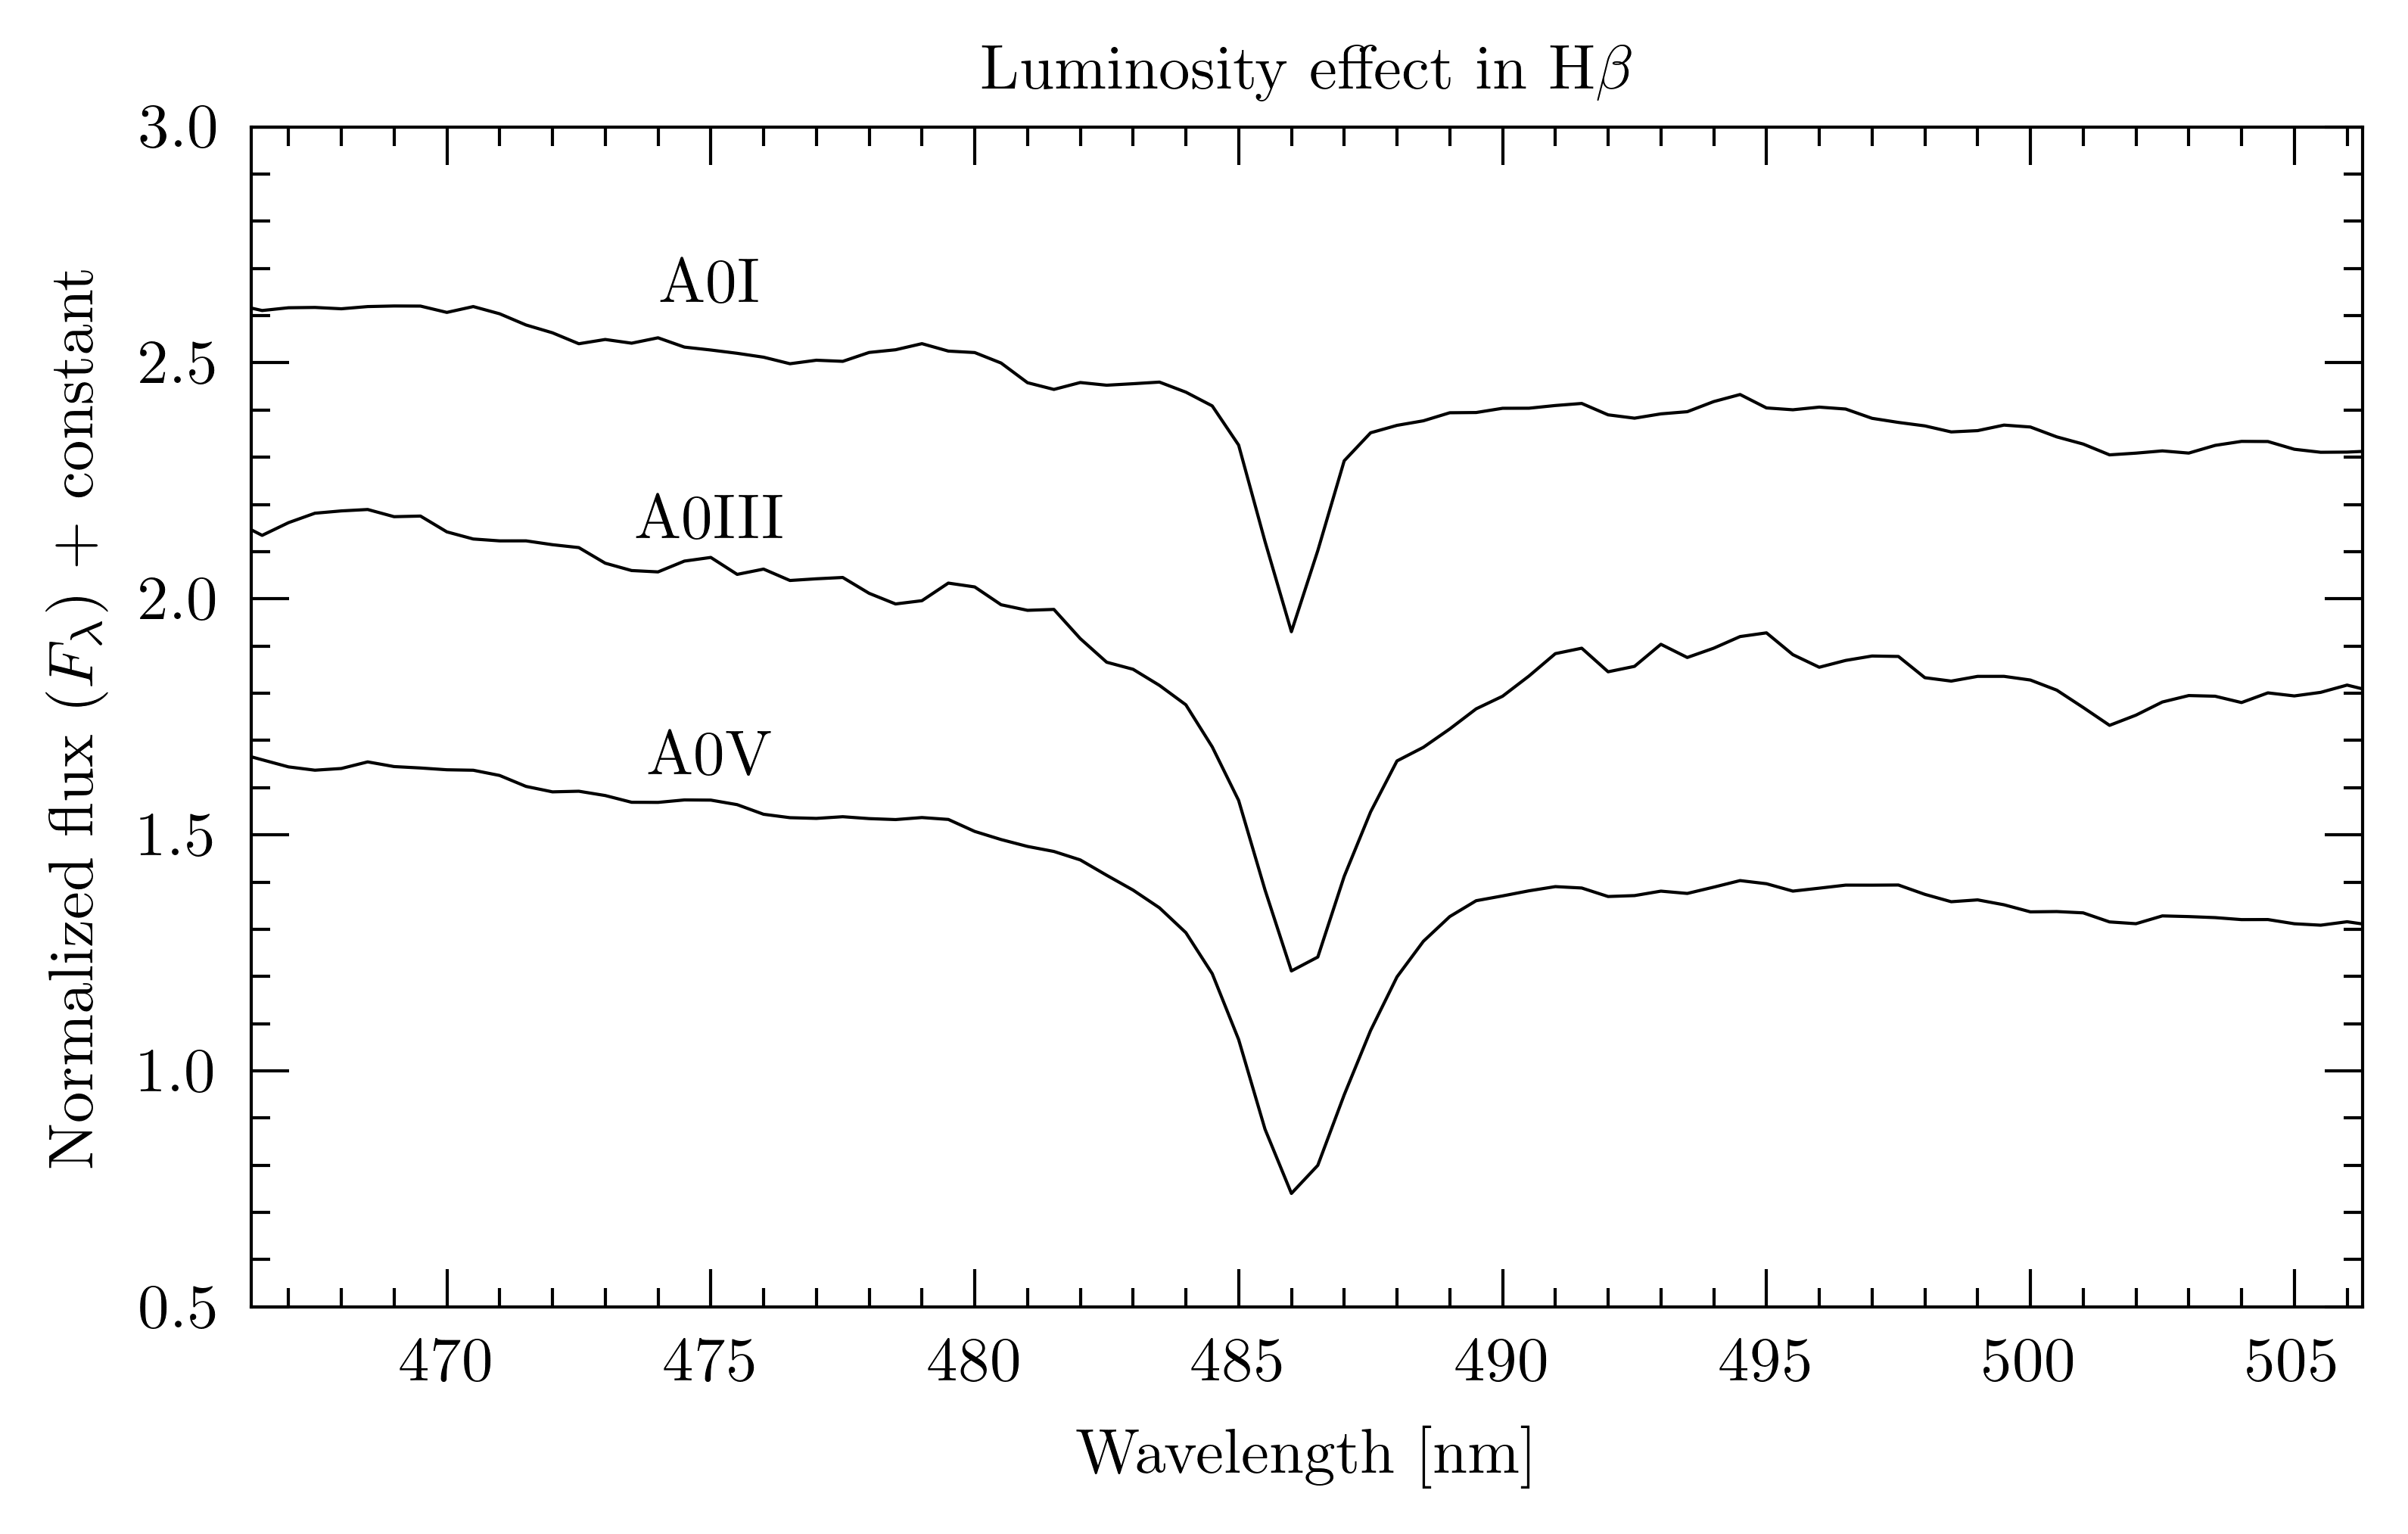

In [6]:
plotFile = 'Luminosity_A0.png' 

dataDir = 'Pickles' # TRDS Pickles Atlas
spTypes = ['a0v','a0iii','a0i']

lamStar = {}
flxStar = {}
for spt in spTypes:
    fitsFile = f'{dataDir}/J_PASP_110_863_{spt}.dat.fits'
    hdu = fits.open(fitsFile)
    data = hdu[1].data
    lamStar[spt] = lamScale*np.array(data['lambda']) # convert to nm
    flxStar[spt] = np.array(data['nflam']) # normalized f_lambda

# wavelength region of interest around H-beta

lMin = lamScale*(4863-200)
lMax = lamScale*(4863+200)
lMajor = lamScale*50.
lMinor = lamScale*10.

fMin = 0.5
fMax = 3.0

# 

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

ax.set_xlim(lMin,lMax)
ax.xaxis.set_major_locator(MultipleLocator(lMajor))
ax.xaxis.set_minor_locator(MultipleLocator(lMinor))
if specUnits == 'nm':
    ax.set_xlabel(r'Wavelength [nm]',fontsize=axisFontSize)
else:
    ax.set_xlabel(r'Wavelength [\AA]',fontsize=axisFontSize)

ax.set_ylim(fMin,fMax)
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_ylabel(r'Normalized flux ($F_\lambda$) + constant',fontsize=axisFontSize)

for i in range(len(spTypes)):
    spt = spTypes[i]
    flxOff = i*0.5
    ax.plot(lamStar[spt],flxStar[spt]+flxOff,'-',color='black',lw=0.5)
    ax.text(475,1.6+flxOff,spt.upper(),va='bottom',ha='center',fontsize=axisFontSize)

ax.set_title(r'Luminosity effect in H$\beta$',fontsize=axisFontSize)

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')
plt.show()